# 00 — ABIDES Hello World

This notebook:
1. Runs the **RMSC03** reference market simulation for ~1 simulated hour
2. Plots the **mid-price** over time
3. Plots a **LOB snapshot** (top 10 levels each side) at one moment

Agents: 1 Exchange · 1 Adaptive Market Maker · 20 Value · 5 Momentum · 200 Noise

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from abides_core import abides
from abides_core.utils import ns_date, str_to_ns, fmt_ts
from abides_markets.configs import rmsc03_simple

print('All imports OK ✓')

All imports OK ✓


## 1. Build config and run simulation

We simulate from **09:30** to **10:30** (1 simulated hour).  
This takes roughly 1–3 minutes — the cell is running as long as you see `In [*]` on the left.

In [2]:
config = rmsc03_simple.build_config(
    start_time="09:30:00",
    end_time="10:30:00",
    seed=42,
)

print("Config built — starting simulation...")
end_state = abides.run(config)
print("Simulation complete ✓")

Config built — starting simulation...
Simulation complete ✓


## 2. Extract order book data

In [3]:
order_book = end_state["agents"][0].order_books["ABM"]

L1 = order_book.get_L1_snapshots()
best_bids = pd.DataFrame(L1["best_bids"], columns=["time", "price", "qty"])
best_asks = pd.DataFrame(L1["best_asks"], columns=["time", "price", "qty"])

best_bids["time"] = best_bids["time"].apply(lambda x: x - ns_date(x))
best_asks["time"] = best_asks["time"].apply(lambda x: x - ns_date(x))

merged = pd.merge_asof(
    best_bids.sort_values("time"),
    best_asks.sort_values("time"),
    on="time",
    suffixes=("_bid", "_ask"),
)
merged["mid"] = (merged["price_bid"] + merged["price_ask"]) / 2

L2 = order_book.get_L2_snapshots(nlevels=10)

print(f"L1 snapshots: {len(best_bids)} bid events, {len(best_asks)} ask events")
print(f"L2 snapshots: {len(L2['times'])} events")

L1 snapshots: 35 bid events, 35 ask events
L2 snapshots: 35 events


## 3. Plot (a) — Mid-price over time

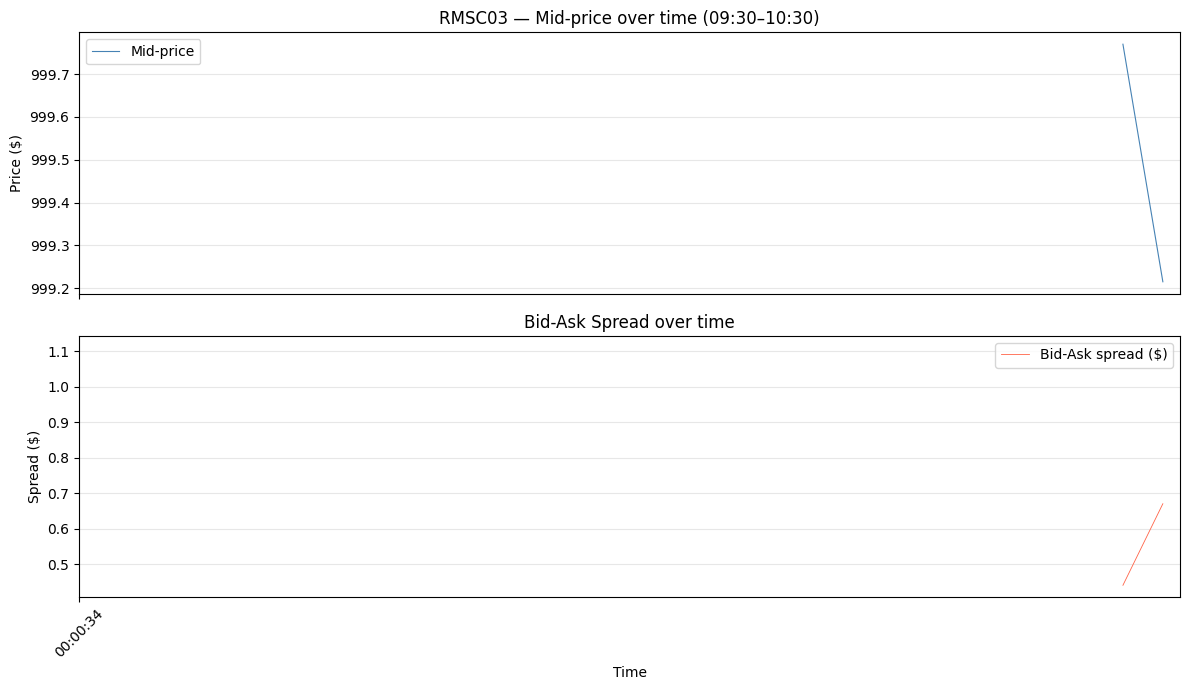

Plot saved as mid_price.png ✓


In [4]:
time_ticks = np.arange(str_to_ns("09:30:00"), str_to_ns("10:31:00"), int(1e9 * 60 * 10))
date_offset = ns_date(L1["best_bids"][0][0])
tick_labels = [fmt_ts(t + date_offset).split(" ")[1] for t in time_ticks]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(merged["time"], merged["mid"] / 100, color="steelblue", linewidth=0.8, label="Mid-price")
ax.set_ylabel("Price ($)")
ax.set_title("RMSC03 — Mid-price over time (09:30–10:30)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(time_ticks)
ax.set_xticklabels(tick_labels, rotation=45)

ax2 = axes[1]
spread = (merged["price_ask"] - merged["price_bid"]) / 100
ax2.plot(merged["time"], spread, color="tomato", linewidth=0.6, label="Bid-Ask spread ($)")
ax2.set_ylabel("Spread ($)")
ax2.set_xlabel("Time")
ax2.set_title("Bid-Ask Spread over time")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(time_ticks)
ax2.set_xticklabels(tick_labels, rotation=45)

plt.tight_layout()
plt.savefig("mid_price.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as mid_price.png ✓")

## 4. Plot (b) — LOB Snapshot at one moment (top 10 levels each side)

IndexError: single positional indexer is out-of-bounds

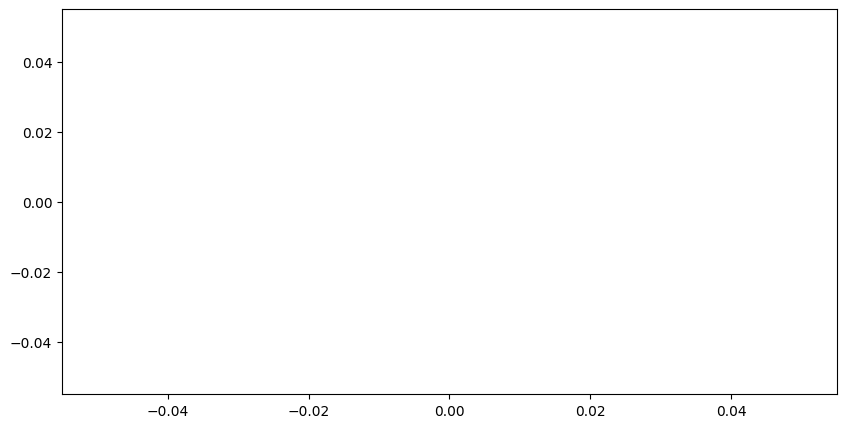

In [5]:
times_ns = np.array([t - ns_date(t) for t in L2["times"]])
target_time = str_to_ns("10:00:00")
snapshot_idx = np.argmin(np.abs(times_ns - target_time))

bids_df = pd.DataFrame(L2["bids"][snapshot_idx], columns=["price", "qty"])
asks_df = pd.DataFrame(L2["asks"][snapshot_idx], columns=["price", "qty"])
bids_df = bids_df[bids_df["price"] > 0].copy()
asks_df = asks_df[asks_df["price"] > 0].copy()
bids_df["price"] /= 100
asks_df["price"] /= 100

snapshot_time_str = fmt_ts(L2["times"][snapshot_idx]).split(" ")[1]
bar_height = (asks_df["price"].max() - bids_df["price"].min()) / 40

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(bids_df["price"], bids_df["qty"], height=bar_height, color="green", alpha=0.7, label="Bids")
ax.barh(asks_df["price"], asks_df["qty"], height=bar_height, color="red",   alpha=0.7, label="Asks")

mid = (bids_df["price"].iloc[0] + asks_df["price"].iloc[0]) / 2
ax.axhline(mid, color="black", linestyle="--", linewidth=0.8, label=f"Mid = ${mid:.2f}")
ax.set_xlabel("Quantity")
ax.set_ylabel("Price ($)")
ax.set_title(f"LOB Snapshot — Top 10 levels each side @ {snapshot_time_str}")
ax.legend()
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("lob_snapshot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"LOB snapshot saved as lob_snapshot.png ✓")

## 5. Quick stats summary

In [ ]:
print("=== Simulation Summary ===")
print(f"Mid-price start : ${merged['mid'].iloc[0]/100:.4f}")
print(f"Mid-price end   : ${merged['mid'].iloc[-1]/100:.4f}")
print(f"Mid-price min   : ${merged['mid'].min()/100:.4f}")
print(f"Mid-price max   : ${merged['mid'].max()/100:.4f}")
print(f"Avg spread      : ${spread.mean():.4f}")
print(f"L1 events       : {len(merged)}")
print(f"L2 snapshots    : {len(L2['times'])}")